# 03 Sentence Embedding Engine

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `03-sentence-embedding-engine.ipynb`

In [2]:
# ==========================================
# Notebook 03
# Sentence Embedding Engine
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [4]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [5]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinna\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
sample_text = claims_df.loc[0, "claimant_statement"]

sample_text

'A vehicle rear-ended me while I was waiting at a traffic signal.'

In [7]:
embedding = embedding_model.encode(sample_text)

In [12]:
embedding.shape

(768,)

In [13]:
embedding[:20]

array([-0.02898847, -0.01141155, -0.02668859,  0.01293947, -0.02481518,
        0.01711428,  0.05214357,  0.01595107, -0.04762283, -0.0062802 ,
        0.06628626, -0.01401573, -0.01808071, -0.06073149,  0.02149805,
        0.04526998, -0.00500253, -0.01585435,  0.01806108, -0.03285902],
      dtype=float32)

In [18]:
claim_embeddings = embedding_model.encode(
    claims_df["claimant_statement"].tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
claim_embeddings

array([[-0.02898851, -0.01141158, -0.02668859, ..., -0.00343934,
         0.04319242, -0.02723617],
       [-0.02883271, -0.05414448, -0.01487921, ..., -0.04543489,
         0.00921732, -0.0129683 ],
       [-0.01716335, -0.05382736, -0.0062689 , ..., -0.01439491,
        -0.0020754 , -0.01129994],
       ...,
       [-0.02898851, -0.01141158, -0.02668859, ..., -0.00343934,
         0.04319242, -0.02723617],
       [-0.06201219,  0.00035249, -0.01164548, ..., -0.01516233,
        -0.00502488, -0.01813465],
       [-0.05811561, -0.04542429, -0.01193421, ..., -0.03145353,
        -0.00380314, -0.01966919]], dtype=float32)

In [20]:
claim_embeddings.shape

(15, 768)

In [21]:
claims_df["embedding"] = list(claim_embeddings)

In [25]:
claims_df["embedding"]

0     [-0.02898851, -0.011411577, -0.026688589, 0.01...
1     [-0.028832708, -0.05414448, -0.014879215, 0.02...
2     [-0.017163347, -0.053827357, -0.006268896, -0....
3     [-0.028832708, -0.05414448, -0.014879215, 0.02...
4     [-0.05811561, -0.045424294, -0.011934207, 0.02...
5     [0.0048476895, 0.020316701, -0.0029129225, 0.0...
6     [-0.05811561, -0.045424294, -0.011934207, 0.02...
7     [-0.06201219, 0.00035249005, -0.01164548, -0.0...
8     [-0.04630496, -0.0001983496, -0.025630247, 0.0...
9     [-0.05811561, -0.045424294, -0.011934207, 0.02...
10    [0.0048476895, 0.020316701, -0.0029129225, 0.0...
11    [-0.04630496, -0.0001983496, -0.025630247, 0.0...
12    [-0.02898851, -0.011411577, -0.026688589, 0.01...
13    [-0.06201219, 0.00035249005, -0.01164548, -0.0...
14    [-0.05811561, -0.045424294, -0.011934207, 0.02...
Name: embedding, dtype: object

In [23]:
statement_a = """
I was stopped at a traffic light when another vehicle hit me from behind.
"""

In [26]:
statement_b = """
While waiting at a red signal, my car was rear-ended.
"""

In [27]:
embedding_a = embedding_model.encode(statement_a)

embedding_b = embedding_model.encode(statement_b)

In [28]:
similarity = cosine_similarity(embedding_a.reshape(1, -1), embedding_b.reshape(1, -1))[
    0
][0]

In [29]:
print(f"Similarity: {similarity:.4f}")

Similarity: 0.7428


In [30]:
statement_c = """
My vehicle was parked overnight in a garage.
"""

In [31]:
embedding_c = embedding_model.encode(statement_c)

In [32]:
cosine_similarity(embedding_a.reshape(1, -1), embedding_c.reshape(1, -1))[0][0]

0.31624165

In [33]:
claim_1 = claims_df.loc[0, "claimant_statement"]

claim_2 = claims_df.loc[1, "claimant_statement"]

In [34]:
emb_1 = embedding_model.encode(claim_1)

emb_2 = embedding_model.encode(claim_2)

In [35]:
similarity = cosine_similarity(emb_1.reshape(1, -1), emb_2.reshape(1, -1))[0][0]

similarity

0.7147998

In [36]:
similarity_matrix = cosine_similarity(claim_embeddings)

In [38]:
similarity_matrix

array([[0.99999994, 0.7147999 , 0.76184785, 0.7147999 , 0.74806726,
        0.4333124 , 0.74806726, 0.64663863, 0.71606314, 0.74806726,
        0.4333124 , 0.71606314, 0.99999994, 0.64663863, 0.74806726],
       [0.7147999 , 1.0000001 , 0.6988872 , 1.0000001 , 0.8636609 ,
        0.5032761 , 0.8636609 , 0.68140835, 0.77724594, 0.8636609 ,
        0.5032761 , 0.77724594, 0.7147999 , 0.68140835, 0.8636609 ],
       [0.76184785, 0.6988872 , 0.9999999 , 0.6988872 , 0.7532312 ,
        0.4319576 , 0.7532312 , 0.63782406, 0.6742158 , 0.7532312 ,
        0.4319576 , 0.6742158 , 0.76184785, 0.63782406, 0.7532312 ],
       [0.7147999 , 1.0000001 , 0.6988872 , 1.0000001 , 0.8636609 ,
        0.5032761 , 0.8636609 , 0.68140835, 0.77724594, 0.8636609 ,
        0.5032761 , 0.77724594, 0.7147999 , 0.68140835, 0.8636609 ],
       [0.74806726, 0.8636609 , 0.7532312 , 0.8636609 , 1.0000002 ,
        0.58850694, 1.0000002 , 0.6921336 , 0.74016225, 1.0000002 ,
        0.58850694, 0.74016225, 0.74806726, 

In [40]:
similarity_df = pd.DataFrame(
    similarity_matrix, index=claims_df["claim_id"], columns=claims_df["claim_id"]
)
similarity_df

claim_id,CLM001,CLM002,CLM003,CLM004,CLM005,CLM006,CLM007,CLM008,CLM009,CLM010,CLM011,CLM012,CLM013,CLM014,CLM015
claim_id,,,,,,,,,,,,,,,
CLM001,1.000000,0.714800,0.761848,0.714800,0.748067,0.433312,0.748067,0.646639,0.716063,0.748067,0.433312,0.716063,1.000000,0.646639,0.748067
CLM002,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
CLM003,0.761848,0.698887,1.000000,0.698887,0.753231,0.431958,0.753231,0.637824,0.674216,0.753231,0.431958,0.674216,0.761848,0.637824,0.753231
CLM004,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
CLM005,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
CLM006,0.433312,0.503276,0.431958,0.503276,0.588507,1.000000,0.588507,0.428851,0.414034,0.588507,1.000000,0.414034,0.433312,0.428851,0.588507
CLM007,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
CLM008,0.646639,0.681408,0.637824,0.681408,0.692134,0.428851,0.692134,1.000000,0.654495,0.692134,0.428851,0.654495,0.646639,1.000000,0.692134
CLM009,0.716063,0.777246,0.674216,0.777246,0.740162,0.414034,0.740162,0.654495,1.000000,0.740162,0.414034,1.000000,0.716063,0.654495,0.740162


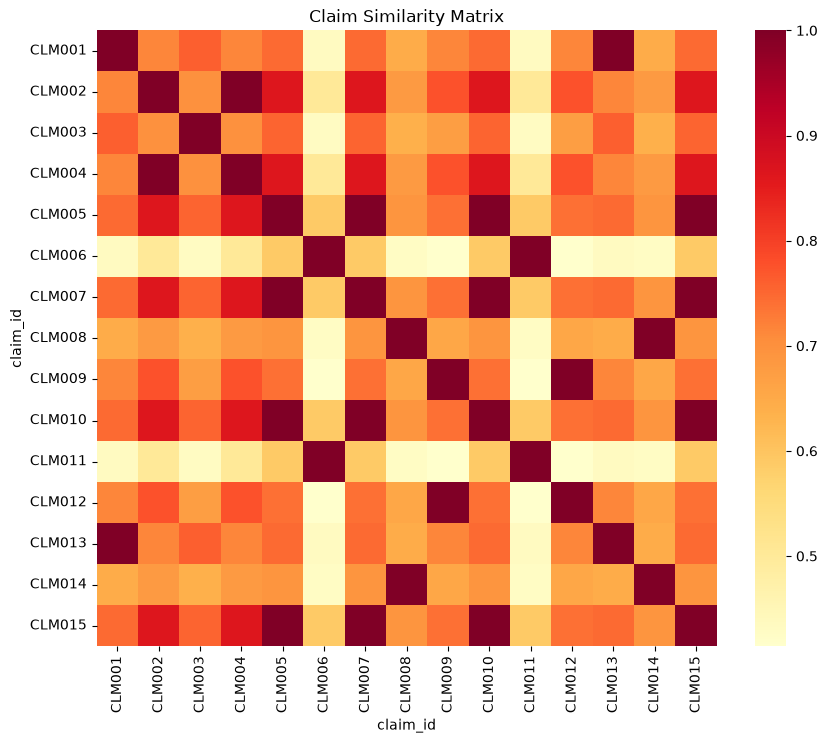

In [41]:
plt.figure(figsize=(10, 8))

sns.heatmap(similarity_df, cmap="YlOrRd")

plt.title("Claim Similarity Matrix")

plt.show()

In [42]:
pairs = []

In [43]:
for i in range(len(claims_df)):

    for j in range(i + 1, len(claims_df)):

        pairs.append(
            {
                "claim_1": claims_df.loc[i, "claim_id"],
                "claim_2": claims_df.loc[j, "claim_id"],
                "similarity": similarity_matrix[i][j],
            }
        )

In [44]:
pairs_df = pd.DataFrame(pairs)

In [46]:
pairs_df

,claim_1,claim_2,similarity
0,CLM001,CLM002,0.714800
1,CLM001,CLM003,0.761848
2,CLM001,CLM004,0.714800
3,CLM001,CLM005,0.748067
4,CLM001,CLM006,0.433312
...,...,...,...
100,CLM012,CLM014,0.654495
101,CLM012,CLM015,0.740162
102,CLM013,CLM014,0.646639
103,CLM013,CLM015,0.748067


In [45]:
pairs_df.sort_values(by="similarity", ascending=False).head(10)

,claim_1,claim_2,similarity
59,CLM005,CLM015,1.0
94,CLM010,CLM015,1.0
54,CLM005,CLM010,1.0
51,CLM005,CLM007,1.0
71,CLM007,CLM010,1.0
76,CLM007,CLM015,1.0
15,CLM002,CLM004,1.0
64,CLM006,CLM011,1.0
11,CLM001,CLM013,1.0
82,CLM008,CLM014,1.0


In [48]:
top_pair = pairs_df.sort_values(by="similarity", ascending=False).iloc[0]
top_pair

claim_1       CLM005
claim_2       CLM015
similarity       1.0
Name: 59, dtype: object

In [49]:
claim_a = claims_df[claims_df["claim_id"] == top_pair["claim_1"]]

In [50]:
claim_b = claims_df[claims_df["claim_id"] == top_pair["claim_2"]]

In [51]:
print(claim_a["claimant_statement"].values[0])

I was driving through an intersection when another vehicle struck my car.


In [ ]:
print(claim_b["claimant_statement"].values[0])

I was driving through an intersection when another vehicle struck my car.


In [53]:
suspicious_pairs = pairs_df[pairs_df["similarity"] > 0.90]

In [54]:
suspicious_pairs

,claim_1,claim_2,similarity
11,CLM001,CLM013,1.0
15,CLM002,CLM004,1.0
51,CLM005,CLM007,1.0
54,CLM005,CLM010,1.0
59,CLM005,CLM015,1.0
64,CLM006,CLM011,1.0
71,CLM007,CLM010,1.0
76,CLM007,CLM015,1.0
82,CLM008,CLM014,1.0
86,CLM009,CLM012,1.0


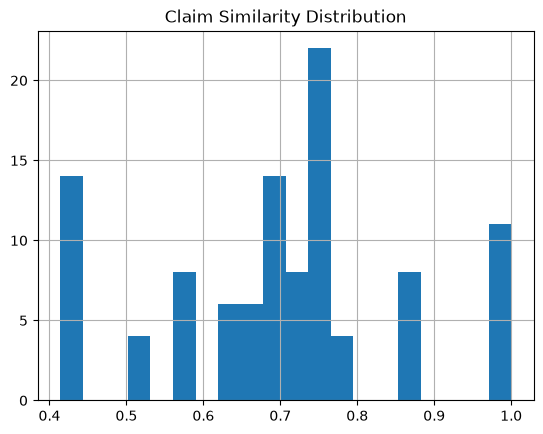

In [55]:
pairs_df["similarity"].hist(bins=20)

plt.title("Claim Similarity Distribution")

plt.show()

In [56]:
pairs_df["similarity"].describe()

count    105.000000
mean       0.698696
std        0.158554
min        0.414034
25%        0.637824
50%        0.714800
75%        0.753231
max        1.000000
Name: similarity, dtype: float64

In [57]:
np.save("../data/claim_embeddings.npy", claim_embeddings)

In [60]:
np

<module 'numpy' from 'd:\\Books\\projects-nlp-transformers-learning\\.projectnlps\\Lib\\site-packages\\numpy\\__init__.py'>

In [59]:
similarity_df

claim_id,CLM001,CLM002,CLM003,CLM004,CLM005,CLM006,CLM007,CLM008,CLM009,CLM010,CLM011,CLM012,CLM013,CLM014,CLM015
claim_id,,,,,,,,,,,,,,,
CLM001,1.000000,0.714800,0.761848,0.714800,0.748067,0.433312,0.748067,0.646639,0.716063,0.748067,0.433312,0.716063,1.000000,0.646639,0.748067
CLM002,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
CLM003,0.761848,0.698887,1.000000,0.698887,0.753231,0.431958,0.753231,0.637824,0.674216,0.753231,0.431958,0.674216,0.761848,0.637824,0.753231
CLM004,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
CLM005,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
CLM006,0.433312,0.503276,0.431958,0.503276,0.588507,1.000000,0.588507,0.428851,0.414034,0.588507,1.000000,0.414034,0.433312,0.428851,0.588507
CLM007,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
CLM008,0.646639,0.681408,0.637824,0.681408,0.692134,0.428851,0.692134,1.000000,0.654495,0.692134,0.428851,0.654495,0.646639,1.000000,0.692134
CLM009,0.716063,0.777246,0.674216,0.777246,0.740162,0.414034,0.740162,0.654495,1.000000,0.740162,0.414034,1.000000,0.716063,0.654495,0.740162


In [58]:
similarity_df.to_csv("../data/claim_similarity_matrix.csv")